In [1]:
import os
import shutil
import random

from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image

In [2]:
DATASET_PATH = (
    "/kaggle/input/datasets/salmankey/"
    "scoliosis-yolov5-annotated-spine-x-ray-dataset/"
    "scoliosis yolov5"
)

TRAIN_IMG = os.path.join(DATASET_PATH, "train/images")
TRAIN_LABEL = os.path.join(DATASET_PATH, "train/labels")

VALID_IMG = os.path.join(DATASET_PATH, "valid/images")
VALID_LABEL = os.path.join(DATASET_PATH, "valid/labels")

TEST_IMG = os.path.join(DATASET_PATH, "test/images")
TEST_LABEL = os.path.join(DATASET_PATH, "test/labels")

In [3]:
print("TRAIN :", len(list(Path(TRAIN_LABEL).glob("*.txt"))))
print("VALID :", len(list(Path(VALID_LABEL).glob("*.txt"))))
print("TEST  :", len(list(Path(TEST_LABEL).glob("*.txt"))))

TRAIN : 1535
VALID : 100
TEST  : 101


In [4]:
counter = Counter()

for txt_file in Path(TRAIN_LABEL).glob("*.txt"):

    with open(txt_file, "r") as f:

        for line in f:

            cls = int(line.split()[0])

            counter[cls] += 1

print(counter)

Counter({0: 23554, 1: 1295, 2: 221})


In [5]:
OUTPUT_DIR = "/kaggle/working/classification_dataset"

for split in ["train", "valid", "test"]:

    os.makedirs(
        os.path.join(OUTPUT_DIR, split, "normal"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(OUTPUT_DIR, split, "scoliosis"),
        exist_ok=True
    )

print("Folder berhasil dibuat.")

Folder berhasil dibuat.


In [6]:
def get_image_class(label_file):

    classes = set()

    with open(label_file, "r") as f:

        for line in f:

            cls = int(line.split()[0])

            classes.add(cls)

    if 1 in classes:
        return "scoliosis"

    elif 2 in classes:
        return "normal"

    return None

In [7]:
def convert_split(img_dir, label_dir, split):

    counter = Counter()

    for txt_file in Path(label_dir).glob("*.txt"):

        label = get_image_class(txt_file)

        if label is None:
            continue

        image_name = txt_file.stem

        found = False

        for ext in [".jpg", ".jpeg", ".png"]:

            img_path = os.path.join(
                img_dir,
                image_name + ext
            )

            if os.path.exists(img_path):

                dst = os.path.join(
                    OUTPUT_DIR,
                    split,
                    label,
                    os.path.basename(img_path)
                )

                shutil.copy(img_path, dst)

                counter[label] += 1

                found = True
                break

        if not found:
            print(f"Image not found: {image_name}")

    return counter

In [8]:
train_count = convert_split(
    TRAIN_IMG,
    TRAIN_LABEL,
    "train"
)

valid_count = convert_split(
    VALID_IMG,
    VALID_LABEL,
    "valid"
)

test_count = convert_split(
    TEST_IMG,
    TEST_LABEL,
    "test"
)

In [9]:
print("TRAIN")
print(train_count)

print("\nVALID")
print(valid_count)

print("\nTEST")
print(test_count)

TRAIN
Counter({'scoliosis': 1291, 'normal': 221})

VALID
Counter({'scoliosis': 88, 'normal': 12})

TEST
Counter({'scoliosis': 65, 'normal': 33})


In [10]:
for split in ["train", "valid", "test"]:

    print(f"\n=== {split.upper()} ===")

    for cls in ["normal", "scoliosis"]:

        folder = os.path.join(
            OUTPUT_DIR,
            split,
            cls
        )

        count = len(os.listdir(folder))

        print(f"{cls}: {count}")


=== TRAIN ===
normal: 221
scoliosis: 1291

=== VALID ===
normal: 12
scoliosis: 88

=== TEST ===
normal: 33
scoliosis: 65


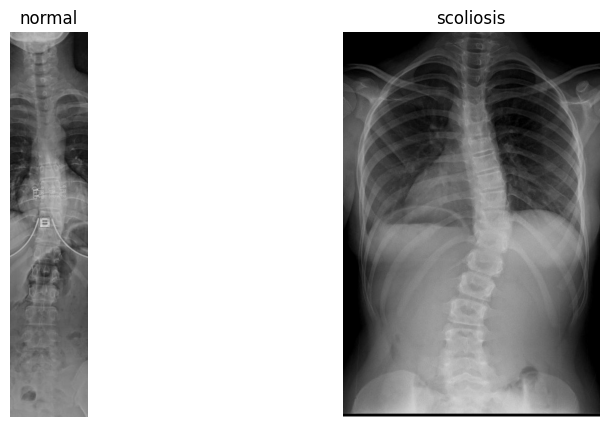

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10,5)
)

for i, cls in enumerate([
    "normal",
    "scoliosis"
]):

    folder = os.path.join(
        OUTPUT_DIR,
        "train",
        cls
    )

    img_file = random.choice(
        os.listdir(folder)
    )

    img_path = os.path.join(
        folder,
        img_file
    )

    img = Image.open(img_path)

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

In [12]:
print("="*50)
print("DATASET CLASSIFICATION BERHASIL DIBUAT")
print("="*50)

for split in ["train", "valid", "test"]:

    normal_count = len(
        os.listdir(
            os.path.join(
                OUTPUT_DIR,
                split,
                "normal"
            )
        )
    )

    scoliosis_count = len(
        os.listdir(
            os.path.join(
                OUTPUT_DIR,
                split,
                "scoliosis"
            )
        )
    )

    print(f"\n{split.upper()}")
    print(f"Normal    : {normal_count}")
    print(f"Scoliosis : {scoliosis_count}")

DATASET CLASSIFICATION BERHASIL DIBUAT

TRAIN
Normal    : 221
Scoliosis : 1291

VALID
Normal    : 12
Scoliosis : 88

TEST
Normal    : 33
Scoliosis : 65


In [13]:
import os

print(
    len(
        os.listdir(
            "/kaggle/working/classification_dataset/train/normal"
        )
    )
)

print(
    len(
        os.listdir(
            "/kaggle/working/classification_dataset/train/scoliosis"
        )
    )
)

221
1291


In [14]:
for split in ["train","valid","test"]:

    for cls in ["normal","scoliosis"]:

        folder = os.path.join(
            OUTPUT_DIR,
            split,
            cls
        )

        print(
            split,
            cls,
            len(os.listdir(folder))
        )

train normal 221
train scoliosis 1291
valid normal 12
valid scoliosis 88
test normal 33
test scoliosis 65


In [15]:
import numpy as np
import pandas as pd

import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

2026-06-24 21:48:58.720043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782337738.956042      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782337739.017602      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782337739.564707      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782337739.564762      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782337739.564765      23 computation_placer.cc:177] computation placer alr

In [16]:
DATASET_DIR = "/kaggle/working/classification_dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VALID_DIR = os.path.join(DATASET_DIR, "valid")
TEST_DIR = os.path.join(DATASET_DIR, "test")

In [17]:
for split in ["train", "valid", "test"]:

    print(f"\n=== {split.upper()} ===")

    for cls in ["normal", "scoliosis"]:

        folder = os.path.join(
            DATASET_DIR,
            split,
            cls
        )

        print(
            cls,
            len(os.listdir(folder))
        )


=== TRAIN ===
normal 221
scoliosis 1291

=== VALID ===
normal 12
scoliosis 88

=== TEST ===
normal 33
scoliosis 65


In [18]:
image_sizes = []

for cls in ["normal", "scoliosis"]:

    folder = os.path.join(TRAIN_DIR, cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:

            img = Image.open(img_path)

            image_sizes.append(img.size)

        except:
            pass

print("Jumlah gambar:", len(image_sizes))

Jumlah gambar: 1512


In [19]:
widths = [w for w, h in image_sizes]
heights = [h for w, h in image_sizes]

print("WIDTH")
print("Min :", min(widths))
print("Max :", max(widths))
print("Mean:", round(np.mean(widths),2))

print()

print("HEIGHT")
print("Min :", min(heights))
print("Max :", max(heights))
print("Mean:", round(np.mean(heights),2))

WIDTH
Min : 111
Max : 2048
Mean: 629.4

HEIGHT
Min : 201
Max : 2048
Mean: 1227.9


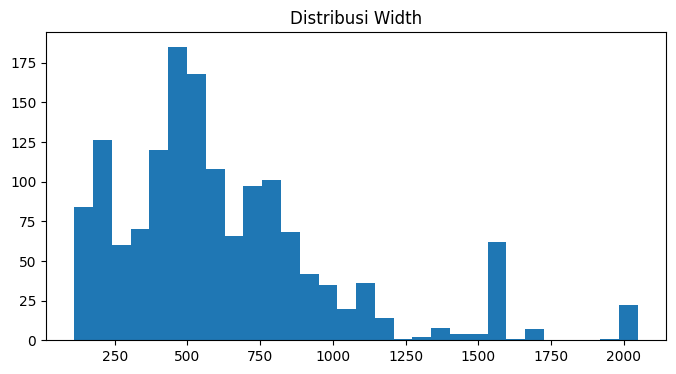

In [20]:
plt.figure(figsize=(8,4))
plt.hist(widths, bins=30)
plt.title("Distribusi Width")
plt.show()

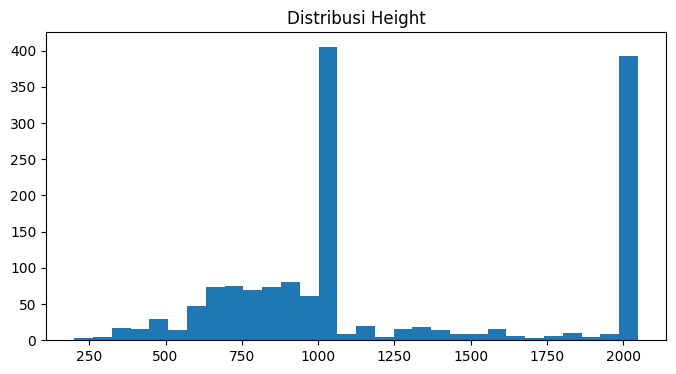

In [21]:
plt.figure(figsize=(8,4))
plt.hist(heights, bins=30)
plt.title("Distribusi Height")
plt.show()

In [22]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

In [23]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

    rescale=1./255,

    rotation_range=10,

    width_shift_range=0.05,

    height_shift_range=0.05,

    zoom_range=0.10,

    brightness_range=[0.9, 1.1],

    horizontal_flip=True
)

In [24]:
valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

In [25]:
train_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=True,

    seed=SEED
)

Found 1512 images belonging to 2 classes.


In [26]:
valid_generator = valid_datagen.flow_from_directory(

    VALID_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=False
)

Found 100 images belonging to 2 classes.


In [27]:
test_generator = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=False
)

Found 98 images belonging to 2 classes.


In [28]:
print(train_generator.class_indices)

{'normal': 0, 'scoliosis': 1}


In [29]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(3.420814479638009), 1: np.float64(0.5855925639039504)}


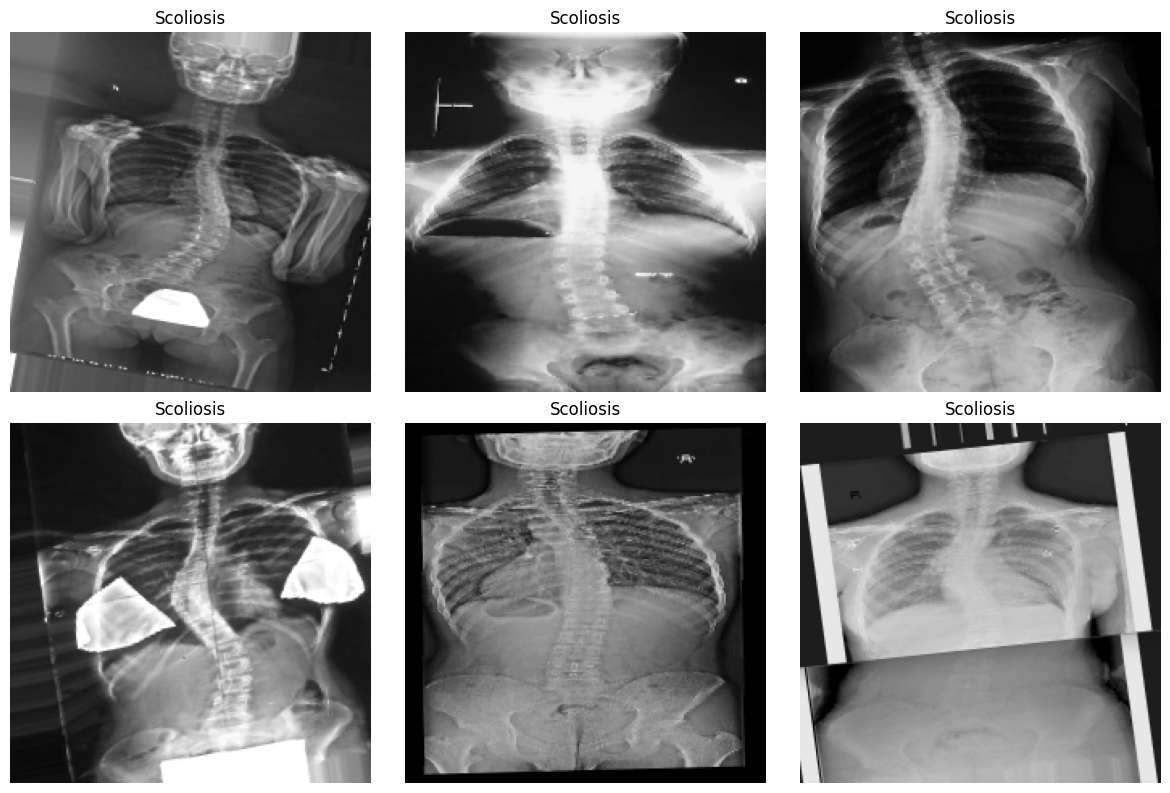

In [30]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.title(
        "Normal"
        if labels[i] == 0
        else "Scoliosis"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Pipeline

In [31]:
from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import (
    ResNet50,
    DenseNet121
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

from tensorflow.keras.optimizers import Adam

In [32]:
EPOCHS = 20

LEARNING_RATE = 0.001

INPUT_SHAPE = (224, 224, 3)

In [33]:
#Resnet 
def build_resnet50():

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    base_model.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.3)(x)

    output = Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs=base_model.input,
        outputs=output
    )

    model.compile(

        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [34]:
#DenseNet
def build_densenet121():

    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    base_model.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.3)(x)

    output = Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs=base_model.input,
        outputs=output
    )

    model.compile(

        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [35]:
resnet_model = build_resnet50()

densenet_model = build_densenet121()

I0000 00:00:1782337757.316808      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782337757.322743      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
resnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
densenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [38]:
print(
    "ResNet50 Trainable Params:",
    np.sum([
        np.prod(v.shape)
        for v in resnet_model.trainable_weights
    ])
)

ResNet50 Trainable Params: 2049


In [39]:
print(
    "DenseNet121 Trainable Params:",
    np.sum([
        np.prod(v.shape)
        for v in densenet_model.trainable_weights
    ])
)

DenseNet121 Trainable Params: 1025


In [40]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)

In [41]:
# Checkpoint ResNet
resnet_checkpoint = ModelCheckpoint(

    filepath="best_resnet50.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

In [42]:
#Checkpoint DenseNet
densenet_checkpoint = ModelCheckpoint(

    filepath="best_densenet121.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

In [43]:
#CSV ResNet
resnet_logger = CSVLogger(
    "resnet50_log.csv"
)

In [44]:
#CSV DenseNet
densenet_logger = CSVLogger(
    "densenet121_log.csv"
)

In [45]:
print("="*50)
print("PIPELINE BERHASIL DIBUAT")
print("="*50)

print("\nDataset")
print("Train Generator :", train_generator is not None)
print("Valid Generator :", valid_generator is not None)
print("Test Generator  :", test_generator is not None)

print("\nClass Weight")
print(class_weights)

print("\nModel")
print("ResNet50     :", resnet_model is not None)
print("DenseNet121  :", densenet_model is not None)

print("\nCallbacks")
print("EarlyStopping      :", early_stopping is not None)
print("ResNet Checkpoint  :", resnet_checkpoint is not None)
print("DenseNet Checkpoint:", densenet_checkpoint is not None)
print("ResNet CSV Logger  :", resnet_logger is not None)
print("DenseNet CSV Logger:", densenet_logger is not None)

PIPELINE BERHASIL DIBUAT

Dataset
Train Generator : True
Valid Generator : True
Test Generator  : True

Class Weight
{0: np.float64(3.420814479638009), 1: np.float64(0.5855925639039504)}

Model
ResNet50     : True
DenseNet121  : True

Callbacks
EarlyStopping      : True
ResNet Checkpoint  : True
DenseNet Checkpoint: True
ResNet CSV Logger  : True
DenseNet CSV Logger: True


In [46]:
#Plot History
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)

    plt.plot(
        history.history['accuracy'],
        label='Train Accuracy'
    )

    plt.plot(
        history.history['val_accuracy'],
        label='Validation Accuracy'
    )

    plt.title(f'{title} Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)

    plt.plot(
        history.history['loss'],
        label='Train Loss'
    )

    plt.plot(
        history.history['val_loss'],
        label='Validation Loss'
    )

    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

## Training

In [47]:
import os

EXPERIMENT_DIR = "/kaggle/working/experiments"

os.makedirs(
    EXPERIMENT_DIR,
    exist_ok=True
)

print("Experiment directory created")

Experiment directory created


# E1

In [48]:
E1_DIR = os.path.join(
    EXPERIMENT_DIR,
    "E1_ResNet50_LR001"
)

os.makedirs(
    E1_DIR,
    exist_ok=True
)

print(E1_DIR)

/kaggle/working/experiments/E1_ResNet50_LR001


In [49]:
LEARNING_RATE = 0.001

print("Learning Rate:", LEARNING_RATE)

Learning Rate: 0.001


In [50]:
#Checkpoint E1
e1_checkpoint = ModelCheckpoint(

    os.path.join(
        E1_DIR,
        "best_resnet50_e1.keras"
    ),

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

e1_logger = CSVLogger(

    os.path.join(
        E1_DIR,
        "resnet50_e1_log.csv"
    )
)

In [51]:
resnet_e1 = build_resnet50()

In [52]:
#E1
history_e1 = resnet_e1.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=20,

    class_weight=class_weights,

    callbacks=[

        early_stopping,

        e1_checkpoint,

        e1_logger
    ]
)

Epoch 1/20


I0000 00:00:1782337773.181184      95 service.cc:152] XLA service 0x7d7a24001fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782337773.181229      95 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782337773.181236      95 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782337775.007605      95 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/48 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.8906 - loss: 0.8347  

I0000 00:00:1782337779.916299      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.5892 - loss: 0.8091
Epoch 1: val_loss improved from None to 0.69360, saving model to /kaggle/working/experiments/E1_ResNet50_LR001/best_resnet50_e1.keras

Epoch 1: finished saving model to /kaggle/working/experiments/E1_ResNet50_LR001/best_resnet50_e1.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 46s 693ms/step - accuracy: 0.5337 - loss: 0.7565 - val_accuracy: 0.3700 - val_loss: 0.6936
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.5018 - loss: 0.7212
Epoch 2: val_loss improved from 0.69360 to 0.53687, saving model to /kaggle/working/experiments/E1_ResNet50_LR001/best_resnet50_e1.keras

Epoch 2: finished saving model to /kaggle/working/experiments/E1_ResNet50_LR001/best_resnet50_e1.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 480ms/step - accuracy: 0.5655 - loss: 0.6850 - val_accuracy: 0.8800 - val_loss: 0.5369
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.6482 - loss: 0.6542
Epoch 3: val_loss did not improve from

In [53]:
history_df = pd.DataFrame(
    history_e1.history
)

history_df.to_csv(

    os.path.join(
        E1_DIR,
        "history_resnet50_e1.csv"
    ),

    index=False
)

print("History saved")

History saved


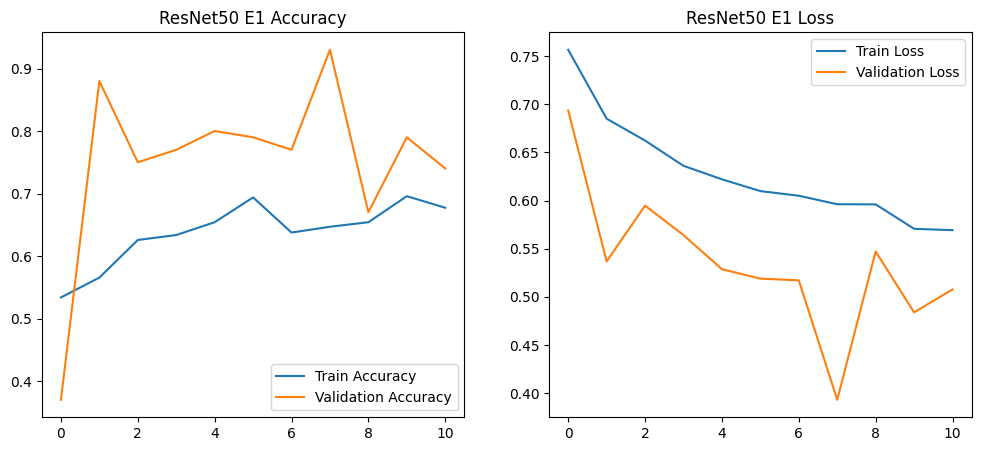

In [54]:
plot_history(
    history_e1,
    "ResNet50 E1"
)

In [55]:
best_epoch = np.argmax(
    history_e1.history['val_accuracy']
)

print("="*50)
print("RINGKASAN E1")
print("="*50)

print(
    "Best Epoch:",
    best_epoch + 1
)

print(
    "Best Validation Accuracy:",
    round(
        max(
            history_e1.history['val_accuracy']
        ),
        4
    )
)

print(
    "Best Validation Loss:",
    round(
        min(
            history_e1.history['val_loss']
        ),
        4
    )
)

RINGKASAN E1
Best Epoch: 8
Best Validation Accuracy: 0.93
Best Validation Loss: 0.3933


# E2 

In [56]:
E2_DIR = os.path.join(
    EXPERIMENT_DIR,
    "E2_ResNet50_LR0005"
)

os.makedirs(
    E2_DIR,
    exist_ok=True
)

print(E2_DIR)

/kaggle/working/experiments/E2_ResNet50_LR0005


In [57]:
LEARNING_RATE = 0.0005

print("Learning Rate:", LEARNING_RATE)

Learning Rate: 0.0005


In [58]:
#Checkpoint E2
e2_checkpoint = ModelCheckpoint(

    os.path.join(
        E2_DIR,
        "best_resnet50_e2.keras"
    ),

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

In [59]:
e2_logger = CSVLogger(

    os.path.join(
        E2_DIR,
        "resnet50_e2_log.csv"
    )
)

In [60]:
resnet_e2 = build_resnet50()

In [61]:
#E2
history_e2 = resnet_e2.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=20,

    class_weight=class_weights,

    callbacks=[

        early_stopping,

        e2_checkpoint,

        e2_logger
    ]
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.6081 - loss: 0.7470
Epoch 1: val_loss improved from None to 0.64746, saving model to /kaggle/working/experiments/E2_ResNet50_LR0005/best_resnet50_e2.keras

Epoch 1: finished saving model to /kaggle/working/experiments/E2_ResNet50_LR0005/best_resnet50_e2.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 42s 673ms/step - accuracy: 0.5377 - loss: 0.7363 - val_accuracy: 0.8400 - val_loss: 0.6475
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5725 - loss: 0.6843
Epoch 2: val_loss did not improve from 0.64746
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 506ms/step - accuracy: 0.5688 - loss: 0.6986 - val_accuracy: 0.4300 - val_loss: 0.7005
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.5126 - loss: 0.6823
Epoch 3: val_loss improved from 0.64746 to 0.59750, saving model to /kaggle/working/experiments/E2_ResNet50_LR0005/best_resnet50_e2.keras

Epoch 3: finished saving model to /kaggle/working/experiments/E2_ResNet50_LR0005

In [62]:
history_df = pd.DataFrame(
    history_e2.history
)

history_df.to_csv(

    os.path.join(
        E2_DIR,
        "history_resnet50_e2.csv"
    ),

    index=False
)

print("History saved")

History saved


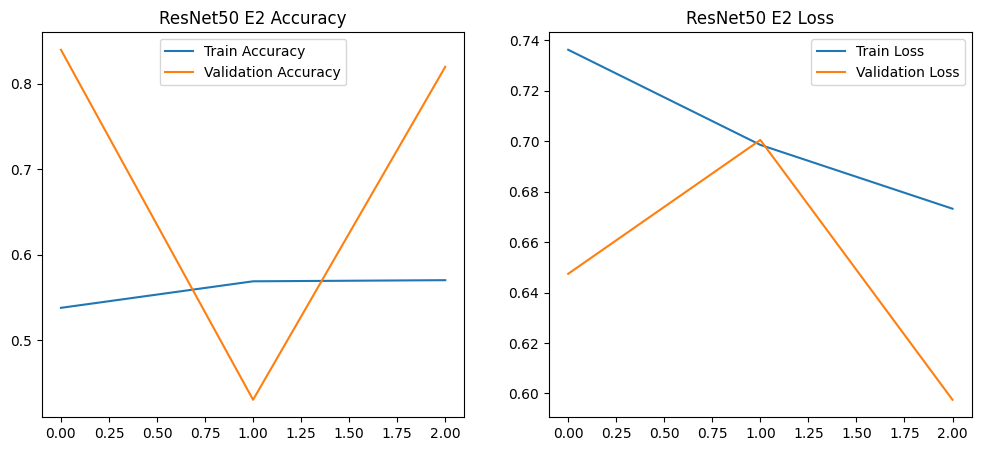

In [63]:
plot_history(
    history_e2,
    "ResNet50 E2"
)

In [64]:
best_epoch = np.argmax(
    history_e2.history['val_accuracy']
)

print("="*50)
print("RINGKASAN E2")
print("="*50)

print(
    "Best Epoch:",
    best_epoch + 1
)

print(
    "Best Validation Accuracy:",
    round(
        max(
            history_e2.history['val_accuracy']
        ),
        4
    )
)

print(
    "Best Validation Loss:",
    round(
        min(
            history_e2.history['val_loss']
        ),
        4
    )
)

RINGKASAN E2
Best Epoch: 1
Best Validation Accuracy: 0.84
Best Validation Loss: 0.5975


# E3

In [65]:
E3_DIR = os.path.join(
    EXPERIMENT_DIR,
    "E3_ResNet50_LR0001"
)

os.makedirs(
    E3_DIR,
    exist_ok=True
)

print(E3_DIR)

/kaggle/working/experiments/E3_ResNet50_LR0001


In [66]:
LEARNING_RATE = 0.0001

print("Learning Rate:", LEARNING_RATE)

Learning Rate: 0.0001


In [67]:
early_stopping_e3 = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)

In [68]:
#Checkpoint E3
e3_checkpoint = ModelCheckpoint(

    os.path.join(
        E3_DIR,
        "best_resnet50_e3.keras"
    ),

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

e3_logger = CSVLogger(

    os.path.join(
        E3_DIR,
        "resnet50_e3_log.csv"
    )
)

In [69]:
resnet_e3 = build_resnet50()

In [70]:
#E3
history_e3 = resnet_e3.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=20,

    class_weight=class_weights,

    callbacks=[

        early_stopping_e3,

        e3_checkpoint,

        e3_logger
    ]
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.1629 - loss: 0.8766
Epoch 1: val_loss improved from None to 0.89776, saving model to /kaggle/working/experiments/E3_ResNet50_LR0001/best_resnet50_e3.keras

Epoch 1: finished saving model to /kaggle/working/experiments/E3_ResNet50_LR0001/best_resnet50_e3.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 691ms/step - accuracy: 0.1925 - loss: 0.8365 - val_accuracy: 0.1200 - val_loss: 0.8978
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.3486 - loss: 0.7346
Epoch 2: val_loss improved from 0.89776 to 0.72244, saving model to /kaggle/working/experiments/E3_ResNet50_LR0001/best_resnet50_e3.keras

Epoch 2: finished saving model to /kaggle/working/experiments/E3_ResNet50_LR0001/best_resnet50_e3.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 540ms/step - accuracy: 0.3664 - loss: 0.7263 - val_accuracy: 0.1300 - val_loss: 0.7224
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.4996 - loss: 0.7433
Epoch 3: val_loss impro

In [71]:
history_df = pd.DataFrame(
    history_e3.history
)

history_df.to_csv(

    os.path.join(
        E3_DIR,
        "history_resnet50_e3.csv"
    ),

    index=False
)

print("History saved")

History saved


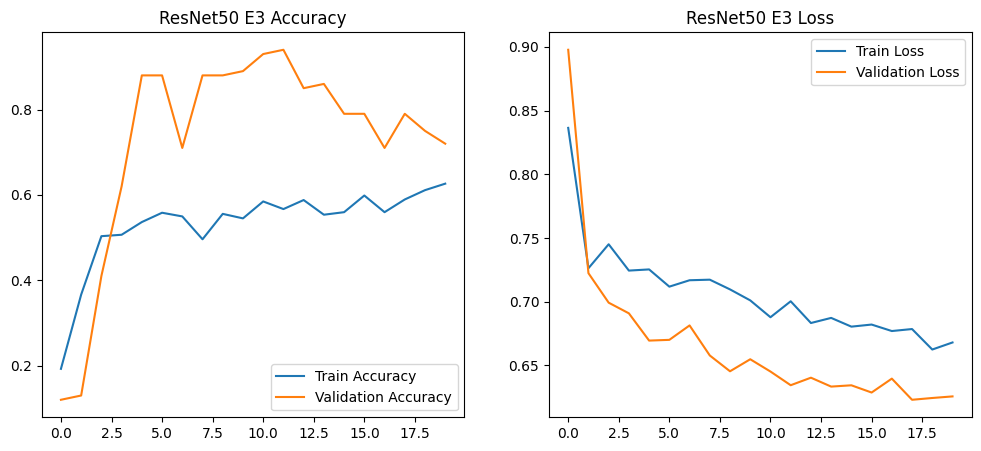

In [72]:
plot_history(
    history_e3,
    "ResNet50 E3"
)

In [73]:
print("="*50)
print("RINGKASAN E3")
print("="*50)

best_acc_epoch = np.argmax(
    history_e3.history['val_accuracy']
)

best_loss_epoch = np.argmin(
    history_e3.history['val_loss']
)

print(
    f"Best Validation Accuracy : {max(history_e3.history['val_accuracy']):.4f}"
)

print(
    f"Epoch Validation Accuracy Terbaik : {best_acc_epoch+1}"
)

print()

print(
    f"Best Validation Loss : {min(history_e3.history['val_loss']):.4f}"
)

print(
    f"Epoch Validation Loss Terbaik : {best_loss_epoch+1}"
)

RINGKASAN E3
Best Validation Accuracy : 0.9400
Epoch Validation Accuracy Terbaik : 12

Best Validation Loss : 0.6231
Epoch Validation Loss Terbaik : 18


# DenseNet

# E4

In [74]:
E4_DIR = os.path.join(
    EXPERIMENT_DIR,
    "E4_DenseNet121_LR001"
)

os.makedirs(
    E4_DIR,
    exist_ok=True
)

print(E4_DIR)

/kaggle/working/experiments/E4_DenseNet121_LR001


In [75]:
LEARNING_RATE = 0.001

print("Learning Rate:", LEARNING_RATE)

Learning Rate: 0.001


In [76]:
early_stopping_e4 = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)

In [77]:
#Checkpoint E4
e4_checkpoint = ModelCheckpoint(

    os.path.join(
        E4_DIR,
        "best_densenet121_e4.keras"
    ),

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

e4_logger = CSVLogger(

    os.path.join(
        E4_DIR,
        "densenet121_e4_log.csv"
    )
)

In [78]:
densenet_e4 = build_densenet121()

In [79]:
#E4
history_e4 = densenet_e4.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=20,

    class_weight=class_weights,

    callbacks=[

        early_stopping_e4,

        e4_checkpoint,

        e4_logger
    ]
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.7324 - loss: 0.7473
Epoch 1: val_loss improved from None to 0.28271, saving model to /kaggle/working/experiments/E4_DenseNet121_LR001/best_densenet121_e4.keras

Epoch 1: finished saving model to /kaggle/working/experiments/E4_DenseNet121_LR001/best_densenet121_e4.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.7639 - loss: 0.5926 - val_accuracy: 0.9500 - val_loss: 0.2827
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8410 - loss: 0.4564
Epoch 2: val_loss improved from 0.28271 to 0.20477, saving model to /kaggle/working/experiments/E4_DenseNet121_LR001/best_densenet121_e4.keras

Epoch 2: finished saving model to /kaggle/working/experiments/E4_DenseNet121_LR001/best_densenet121_e4.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 510ms/step - accuracy: 0.8552 - loss: 0.4165 - val_accuracy: 0.9700 - val_loss: 0.2048
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8815 - loss: 0.3837
Epoch 

In [80]:
history_df = pd.DataFrame(
    history_e4.history
)

history_df.to_csv(

    os.path.join(
        E4_DIR,
        "history_densenet121_e4.csv"
    ),

    index=False
)

print("History saved")

History saved


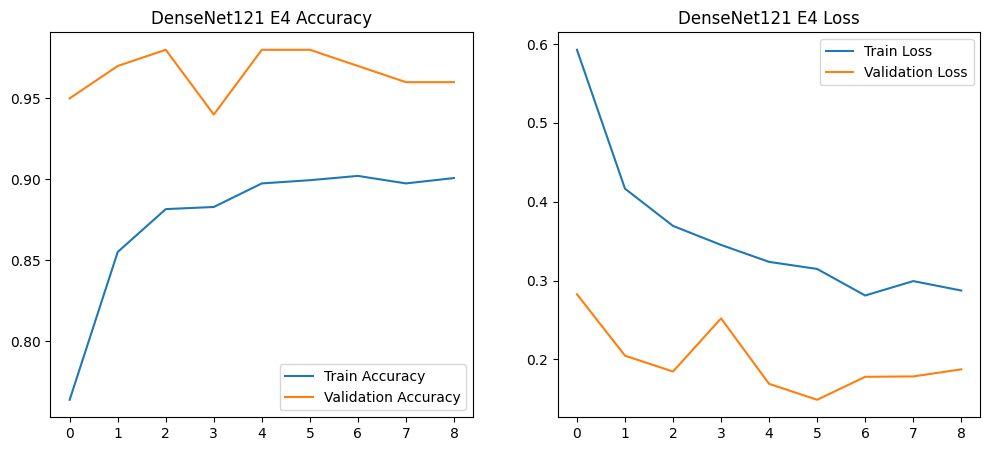

In [81]:
plot_history(
    history_e4,
    "DenseNet121 E4"
)

In [82]:
print("="*50)
print("RINGKASAN E4")
print("="*50)

best_acc_epoch = np.argmax(
    history_e4.history['val_accuracy']
)

best_loss_epoch = np.argmin(
    history_e4.history['val_loss']
)

print(
    f"Best Validation Accuracy : {max(history_e4.history['val_accuracy']):.4f}"
)

print(
    f"Epoch Validation Accuracy Terbaik : {best_acc_epoch+1}"
)

print()

print(
    f"Best Validation Loss : {min(history_e4.history['val_loss']):.4f}"
)

print(
    f"Epoch Validation Loss Terbaik : {best_loss_epoch+1}"
)

RINGKASAN E4
Best Validation Accuracy : 0.9800
Epoch Validation Accuracy Terbaik : 3

Best Validation Loss : 0.1489
Epoch Validation Loss Terbaik : 6


In [83]:
E5_DIR = os.path.join(
    EXPERIMENT_DIR,
    "E5_DenseNet121_LR0005"
)

os.makedirs(
    E5_DIR,
    exist_ok=True
)

print(E5_DIR)

/kaggle/working/experiments/E5_DenseNet121_LR0005


In [84]:
LEARNING_RATE = 0.0005

print("Learning Rate:", LEARNING_RATE)

Learning Rate: 0.0005


In [85]:
early_stopping_e5 = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)

In [86]:
#Checkpoint E5
e5_checkpoint = ModelCheckpoint(

    os.path.join(
        E5_DIR,
        "best_densenet121_e5.keras"
    ),

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

e5_logger = CSVLogger(

    os.path.join(
        E5_DIR,
        "densenet121_e5_log.csv"
    )
)

In [87]:
densenet_e5 = build_densenet121()

In [88]:
# E5
history_e5 = densenet_e5.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=20,

    class_weight=class_weights,

    callbacks=[

        early_stopping_e5,

        e5_checkpoint,

        e5_logger
    ]
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.5954 - loss: 0.7888
Epoch 1: val_loss improved from None to 0.60320, saving model to /kaggle/working/experiments/E5_DenseNet121_LR0005/best_densenet121_e5.keras

Epoch 1: finished saving model to /kaggle/working/experiments/E5_DenseNet121_LR0005/best_densenet121_e5.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6574 - loss: 0.7549 - val_accuracy: 0.6400 - val_loss: 0.6032
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.7090 - loss: 0.5854
Epoch 2: val_loss improved from 0.60320 to 0.28014, saving model to /kaggle/working/experiments/E5_DenseNet121_LR0005/best_densenet121_e5.keras

Epoch 2: finished saving model to /kaggle/working/experiments/E5_DenseNet121_LR0005/best_densenet121_e5.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 520ms/step - accuracy: 0.7771 - loss: 0.5235 - val_accuracy: 0.9500 - val_loss: 0.2801
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8292 - loss: 0.5021
Ep

In [89]:
history_df = pd.DataFrame(
    history_e5.history
)

history_df.to_csv(

    os.path.join(
        E5_DIR,
        "history_densenet121_e5.csv"
    ),

    index=False
)

print("History saved")

History saved


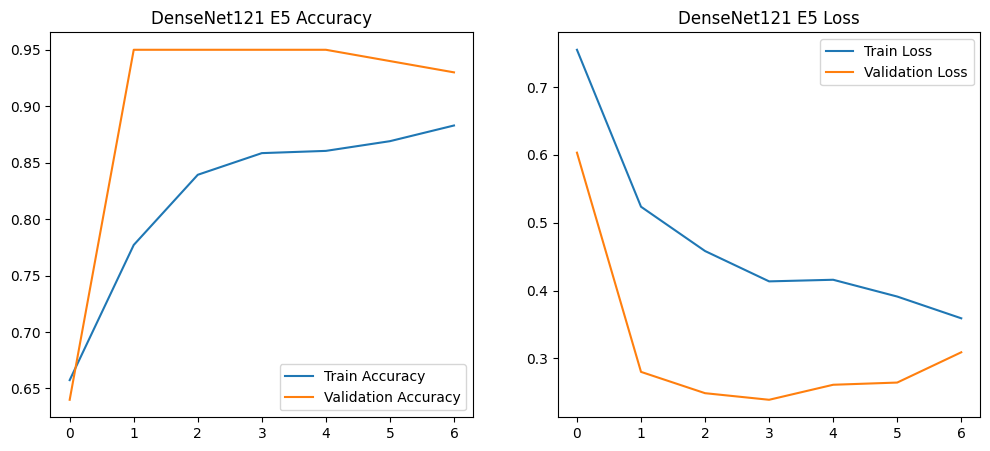

In [90]:
plot_history(
    history_e5,
    "DenseNet121 E5"
)

In [91]:
print("="*50)
print("RINGKASAN E5")
print("="*50)

best_acc_epoch = np.argmax(
    history_e5.history['val_accuracy']
)

best_loss_epoch = np.argmin(
    history_e5.history['val_loss']
)

print(
    f"Best Validation Accuracy : {max(history_e5.history['val_accuracy']):.4f}"
)

print(
    f"Epoch Validation Accuracy Terbaik : {best_acc_epoch+1}"
)

print()

print(
    f"Best Validation Loss : {min(history_e5.history['val_loss']):.4f}"
)

print(
    f"Epoch Validation Loss Terbaik : {best_loss_epoch+1}"
)

RINGKASAN E5
Best Validation Accuracy : 0.9500
Epoch Validation Accuracy Terbaik : 2

Best Validation Loss : 0.2390
Epoch Validation Loss Terbaik : 4
